# PaliGemma-3B · QLoRA · RISC Captioning
Sections:
1. Setup & Configuration
2. Data - RISC Loading, EDA, Image-Level Split
3. Baseline - PaliGemma Zero-Shot Evaluation
4. QLoRA Fine-Tuning
5. Evaluation - Fine-Tuned Model
6. Originality Experiments
7. Final Comparison & Discussion
8. Stretch Goals

## 1. Setup & Configuration


In [ ]:
%pip install -q -U \
  "transformers>=4.45.0" \
  "datasets>=2.20.0" \
  "peft>=0.13.0" \
  "bitsandbytes>=0.46.1" \
  "accelerate>=0.34.0" \
  wandb pycocoevalcap nltk Pillow


In [ ]:
import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import wandb

In [ ]:
CONFIG = {
    "seed": 42,
    "model_id": "google/paligemma-3b-pt-224",
    "dataset_id": "caglarmert/full_riscm",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.bfloat16,

    "prompt": "caption en",
    "caption_strategy": "random",

    "split": {
        "test_size": 0.10,
        "val_size": 0.05,
    },

    "bnb": {
        "load_in_4bit": True,
        "bnb_4bit_quant_type": "nf4",
        "bnb_4bit_use_double_quant": True,
    },

    "lora": {
        "r": 16,
        "alpha": 32,
        "dropout": 0.05,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "use_rslora": True,
        "use_dora": False,
        "lora_plus_lr_ratio": 16,
    },

    "freeze_vision_tower": True,
    "freeze_projector": True,

    "training": {
        "num_train_epochs": 2,
        "per_device_train_batch_size": 4,
        "gradient_accumulation_steps": 4,
        "learning_rate": 1e-4,
        "warmup_ratio": 0.03,
        "weight_decay": 1e-6,
        "logging_steps": 25,
        "eval_steps": 500,
        "save_steps": 500,
        "save_total_limit": 2,
        "output_dir": "checkpoints/paligemma_qlora_risc",
    },

    "eval": {
        "num_qualitative": 8,
        "max_new_tokens": 64,
        "num_beams": 1,
        "smoke_test_n": 50,
        "full_eval": False,
    },

    "wandb": {
        "project": "paligemma3b-QLoRA-RISC",
        "entity": None,
        "run_name": "qlora-r16-lr1e4",
    },
}

RESULTS = {}

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

In [ ]:
from huggingface_hub import login as hf_login

hf_login()
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: sceran to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Data - RISC Loading, EDA, Split


In [ ]:
ds = load_dataset(CONFIG["dataset_id"])
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5'],
        num_rows: 44521
    })
})

In [ ]:
# Schema Inspection: Inspect the first row to confirm the caption field name (likely captions as a list, or caption_1 through caption_5) and adapt the rest of the notebook accordingly.

first = ds["train"][0]
print("columns:", ds["train"].column_names)
print("image type:", type(first["image"]))
{k: v for k, v in first.items() if k != "image"}

columns: ['image', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']
image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


{'caption_1': 'A gray plane on the runway and the lawn beside .',
 'caption_2': 'A grey plane is on the runway by the lawn .',
 'caption_3': 'There is an airplane on the runway with a large lawn by the runway .',
 'caption_4': 'A plane is parked on the runway next to the grass .',
 'caption_5': 'There is a plane on the runway beside the grass .'}

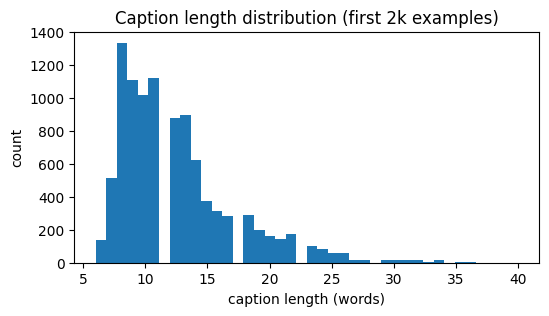

In [ ]:
def collect_captions(example):
    if "captions" in example:
        return list(example["captions"])
    caption_cols = [c for c in example.keys() if c.startswith("caption")]
    return [example[c] for c in sorted(caption_cols)]

lengths = []
for ex in ds["train"].select(range(2000)):
    for cap in collect_captions(ex):
        lengths.append(len(cap.split()))

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=40)
plt.xlabel("caption length (words)")
plt.ylabel("count")
plt.title("Caption length distribution (first 2k examples)")
plt.show()

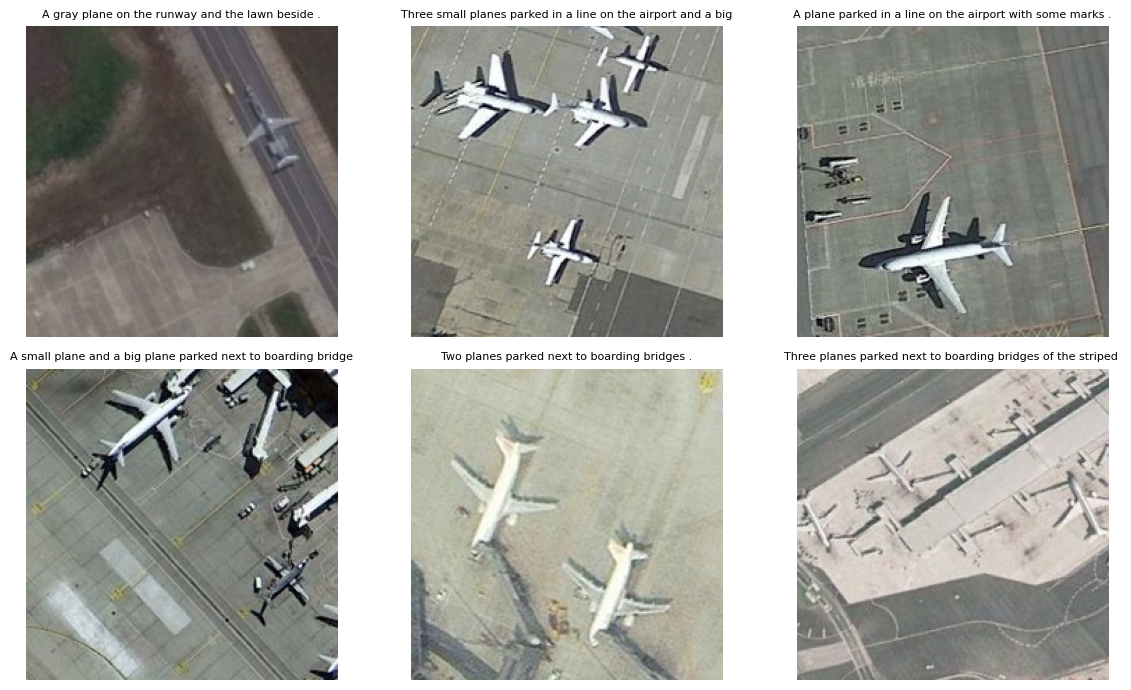

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, ex in zip(axes.flat, ds["train"].select(range(6))):
    ax.imshow(ex["image"])
    ax.axis("off")
    ax.set_title(collect_captions(ex)[0][:60], fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def make_image_level_splits(dataset, test_size, val_size, seed):
    shuffled = dataset.shuffle(seed=seed)
    n = len(shuffled)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    n_train = n - n_test - n_val
    return DatasetDict({
        "train": shuffled.select(range(n_train)),
        "val": shuffled.select(range(n_train, n_train + n_val)),
        "test": shuffled.select(range(n_train + n_val, n)),
    })

splits = make_image_level_splits(
    ds["train"],
    test_size=CONFIG["split"]["test_size"],
    val_size=CONFIG["split"]["val_size"],
    seed=CONFIG["seed"],
)
{k: len(v) for k, v in splits.items()}

{'train': 37843, 'val': 2226, 'test': 4452}

In [ ]:
# Caption Selection Strategy - RISC ships 5 captions per image. Default behaviour: sample one per training step. Other rules are evaluated as the Section 6b ablation.

def select_caption(captions, strategy):
    if strategy == "random":
        return random.choice(captions)
    if strategy == "first":
        return captions[0]
    if strategy == "longest":
        return max(captions, key=len)
    if strategy == "concat":
        return " ".join(captions)
    raise ValueError(strategy)

## 3. Baseline — PaliGemma Zero-Shot Evaluation

Establish the comparison floor before any fine-tuning.

In [ ]:
processor = AutoProcessor.from_pretrained(CONFIG["model_id"])
baseline_model = PaliGemmaForConditionalGeneration.from_pretrained(
    CONFIG["model_id"],
    torch_dtype=CONFIG["dtype"],
).to(CONFIG["device"])
baseline_model.eval();

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

In [ ]:
@torch.no_grad()
def generate_caption(model, processor, image, prompt, max_new_tokens, num_beams):
    inputs = processor(
        text=prompt,
        images=image.convert("RGB"),
        return_tensors="pt",
    ).to(model.device, dtype=CONFIG["dtype"])
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=num_beams,
        do_sample=False,
    )
    text = processor.decode(output_ids[0], skip_special_tokens=True)
    return text[len(prompt):].strip() if text.startswith(prompt) else text.strip()

In [ ]:
# sanity check

_smoke_ex = splits["test"][0]
_smoke_pred = generate_caption(
    baseline_model,
    processor,
    _smoke_ex["image"],
    CONFIG["prompt"],
    CONFIG["eval"]["max_new_tokens"],
    CONFIG["eval"]["num_beams"],
)
print("references:")
for r in collect_captions(_smoke_ex):
    print(" -", r)
print("\nbaseline prediction:", _smoke_pred)

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


references:
 - A dense residential area has a grove of trees and lots of houses .
 - Some of the houses in the residential area are red .
 - There are many roads and neatly arranged houses and trees and large lawns in densely populated areas .
 - The dense residential is on the grass next to the road and trees .
 - There are buildings with green trees around on dense residential area .

baseline prediction: view of homes in the neighborhood .


In [ ]:
# Metric Suite
# Primary: CIDEr (standard for image captioning).
# Classic: BLEU-1, BLEU-4, METEOR, ROUGE-L, SPICE.
# Modern: CLIPScore, RefPAC-S++.

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def compute_caption_metrics(predictions, references):
    """predictions: list[str] of length N. references: list[list[str]] of length N (5 refs per item)."""
    gts = {i: list(refs) for i, refs in enumerate(references)}
    res = {i: [pred] for i, pred in enumerate(predictions)}

    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr"),
    ]

    results = {}
    for scorer, name in scorers:
        score, _ = scorer.compute_score(gts, res)
        if isinstance(name, list):
            for n, s in zip(name, score):
                results[n] = float(s)
        else:
            results[name] = float(score)
    return results

In [ ]:
run = wandb.init(
    project=CONFIG["wandb"]["project"],
    name="baseline-zeroshot",
    config=CONFIG,
    job_type="baseline",
)

In [ ]:
eval_subset = splits["test"] if CONFIG["eval"]["full_eval"] else splits["test"].select(range(CONFIG["eval"]["smoke_test_n"]))
print(f"evaluating baseline on {len(eval_subset)} examples (full_eval={CONFIG['eval']['full_eval']})")

baseline_preds, baseline_refs = [], []
for ex in eval_subset:
    pred = generate_caption(
        baseline_model,
        processor,
        ex["image"],
        CONFIG["prompt"],
        CONFIG["eval"]["max_new_tokens"],
        CONFIG["eval"]["num_beams"],
    )
    baseline_preds.append(pred)
    baseline_refs.append(collect_captions(ex))

RESULTS["baseline"] = compute_caption_metrics(baseline_preds, baseline_refs)
wandb.log({"baseline/" + k: v for k, v in RESULTS["baseline"].items()})
RESULTS["baseline"]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


evaluating baseline on 50 examples (full_eval=False)


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many i

{'testlen': 366, 'reflen': 472, 'guess': [366, 316, 266, 216], 'correct': [161, 32, 10, 1]}
ratio: 0.7754237288119165


{'BLEU-1': 0.3292801223523331,
 'BLEU-2': 0.15798816940430926,
 'BLEU-3': 0.08889201285268059,
 'BLEU-4': 0.039499245362117505,
 'METEOR': 0.09471174069405591,
 'ROUGE-L': 0.26924994647463896,
 'CIDEr': 0.25317934519516444}

In [ ]:
qualitative_indices = list(range(CONFIG["eval"]["num_qualitative"]))
RESULTS["qualitative_indices"] = qualitative_indices

if wandb.run is None:
    wandb.init(project=CONFIG["wandb"]["project"], name="baseline-zeroshot", config=CONFIG, job_type="baseline", resume="allow")

table = wandb.Table(columns=["idx", "image", "ref_1", "ref_2", "ref_3", "ref_4", "ref_5", "baseline"])
for i in qualitative_indices:
    ex = splits["test"][i]
    refs = collect_captions(ex)
    pred = baseline_preds[i]
    table.add_data(i, wandb.Image(ex["image"]), *refs, pred)
wandb.log({"qualitative/baseline": table})

In [ ]:
wandb.finish()

baseline/BLEU-1,▁
baseline/BLEU-2,▁
baseline/BLEU-3,▁
baseline/BLEU-4,▁
baseline/CIDEr,▁
baseline/METEOR,▁
baseline/ROUGE-L,▁
baseline/BLEU-1,0.32928
baseline/BLEU-2,0.15799
baseline/BLEU-3,0.08889
baseline/BLEU-4,0.0395


## 4. QLoRA Fine-Tuning

4-bit NF4 quantization of the base weights + LoRA adapters on the language-model attention and MLP projections. Vision tower and multimodal projector are frozen by default — the standard RS-VLM pattern; Section 6a revisits this choice.

In [ ]:
import transformers
transformers.logging.set_verbosity_error()


In [ ]:
!pip install -U "bitsandbytes>=0.46.1"
import bitsandbytes
print("bnb version:", bitsandbytes.__version__)

import transformers.utils.import_utils as iu
iu._bitsandbytes_available = True


bnb version: 0.49.2


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CONFIG["bnb"]["load_in_4bit"],
    bnb_4bit_quant_type=CONFIG["bnb"]["bnb_4bit_quant_type"],
    bnb_4bit_use_double_quant=CONFIG["bnb"]["bnb_4bit_use_double_quant"],
    bnb_4bit_compute_dtype=CONFIG["dtype"],
)

lora_config = LoraConfig(
    r=CONFIG["lora"]["r"],
    lora_alpha=CONFIG["lora"]["alpha"],
    lora_dropout=CONFIG["lora"]["dropout"],
    target_modules=CONFIG["lora"]["target_modules"],
    task_type="CAUSAL_LM",
    use_rslora=CONFIG["lora"]["use_rslora"],
    use_dora=CONFIG["lora"]["use_dora"],
)

In [ ]:
model = PaliGemmaForConditionalGeneration.from_pretrained(
    CONFIG["model_id"],
    quantization_config=bnb_config,
    device_map={"": 0},
)
model = prepare_model_for_kbit_training(model)

base = model.model if hasattr(model, "model") else model

if CONFIG["freeze_vision_tower"]:
    for p in base.vision_tower.parameters():
        p.requires_grad = False
if CONFIG["freeze_projector"]:
    for p in base.multi_modal_projector.parameters():
        p.requires_grad = False

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

trainable params: 22,597,632 || all params: 2,946,064,112 || trainable%: 0.7670


In [ ]:
# Collator - Builds each batch: caption-strategy-selected target text, standard PaliGemma captioning prompt, image, processed by AutoProcessor with right-padding. The processor handles the '<image>' / '<bos>' token insertion automatically.

def make_collate_fn(processor, strategy, prompt, device, dtype):
    def collate(examples):
        prompts = [prompt] * len(examples)
        targets = [select_caption(collect_captions(ex), strategy) for ex in examples]
        images = [ex["image"].convert("RGB") for ex in examples]
        tokens = processor(
            text=prompts,
            images=images,
            suffix=targets,
            return_tensors="pt",
            padding="longest",
        )
        return tokens.to(dtype).to(device)
    return collate

collate_fn = make_collate_fn(
    processor,
    CONFIG["caption_strategy"],
    CONFIG["prompt"],
    CONFIG["device"],
    CONFIG["dtype"],
)

In [ ]:
# LoRA+ Parameter Groups: Builds optimizer parameter groups for LoRA+: the B matrices receive a higher learning rate than the A matrices (ratio set in `CONFIG["lora"]["lora_plus_lr_ratio"]`). No extra trainable parameters.

def build_lora_plus_param_groups(model, base_lr, lora_plus_ratio):
    A_params, B_params, other_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "lora_A" in name:
            A_params.append(param)
        elif "lora_B" in name:
            B_params.append(param)
        else:
            other_params.append(param)
    return [
        {"params": A_params, "lr": base_lr},
        {"params": B_params, "lr": base_lr * lora_plus_ratio},
        {"params": other_params, "lr": base_lr},
    ]

In [ ]:
# train

training_args = TrainingArguments(
    output_dir=CONFIG["training"]["output_dir"],
    num_train_epochs=1,
    per_device_train_batch_size=CONFIG["training"]["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["training"]["gradient_accumulation_steps"],
    learning_rate=CONFIG["training"]["learning_rate"],
    warmup_ratio=CONFIG["training"]["warmup_ratio"],
    weight_decay=CONFIG["training"]["weight_decay"],
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    bf16=True,
    gradient_checkpointing=True,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="wandb",
    run_name="main-qlora-r16-lr1e4-1ep",
    seed=CONFIG["seed"],
)

param_groups = build_lora_plus_param_groups(
    model,
    base_lr=CONFIG["training"]["learning_rate"],
    lora_plus_ratio=CONFIG["lora"]["lora_plus_lr_ratio"],
)
optimizer = torch.optim.AdamW(param_groups, weight_decay=CONFIG["training"]["weight_decay"])

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=splits["train"],
    eval_dataset=splits["val"],
    data_collator=collate_fn,
    optimizers=(optimizer, None),
)

trainer.train()


{'loss': '2.652', 'grad_norm': '3.806', 'learning_rate': '3.38e-05', 'epoch': '0.01057'}
{'loss': '1.865', 'grad_norm': '3.059', 'learning_rate': '6.901e-05', 'epoch': '0.02114'}
{'loss': '1.784', 'grad_norm': '4.258', 'learning_rate': '9.987e-05', 'epoch': '0.03171'}
{'loss': '1.777', 'grad_norm': '7.939', 'learning_rate': '9.878e-05', 'epoch': '0.04228'}
{'loss': '1.608', 'grad_norm': '4.254', 'learning_rate': '9.769e-05', 'epoch': '0.05285'}
{'loss': '1.526', 'grad_norm': '4.804', 'learning_rate': '9.66e-05', 'epoch': '0.06342'}
{'loss': '1.543', 'grad_norm': '5.666', 'learning_rate': '9.551e-05', 'epoch': '0.07399'}
{'loss': '1.527', 'grad_norm': '6.026', 'learning_rate': '9.442e-05', 'epoch': '0.08456'}
{'loss': '1.547', 'grad_norm': '5.296', 'learning_rate': '9.333e-05', 'epoch': '0.09513'}
{'loss': '1.415', 'grad_norm': '5.781', 'learning_rate': '9.224e-05', 'epoch': '0.1057'}
{'loss': '1.437', 'grad_norm': '5.77', 'learning_rate': '9.115e-05', 'epoch': '0.1163'}
{'loss': '1.369

TrainOutput(global_step=2366, training_loss=1.1112731206447315, metrics={'train_runtime': 8529.3061, 'train_samples_per_second': 4.437, 'train_steps_per_second': 0.277, 'train_loss': 1.1112731206447315, 'epoch': 1.0})

In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   58G  179G  25% /


## 5. Evaluation — Fine-Tuned Model

Generate captions on the same test split with the fine-tuned model. Reuses the qualitative indices from Section 3 so the Section 7 figure shows a clean baseline -> fine-tuned diff for the report.

In [ ]:
n_ft_eval = 500
ft_eval_subset = splits["test"].select(range(n_ft_eval))

if wandb.run is None:
    wandb.init(project=CONFIG["wandb"]["project"], name="main-qlora-eval", config=CONFIG, job_type="eval", resume="allow")

ft_model = trainer.model
ft_model.eval()

ft_preds, ft_refs = [], []
for ex in ft_eval_subset:
    pred = generate_caption(
        ft_model,
        processor,
        ex["image"],
        CONFIG["prompt"],
        CONFIG["eval"]["max_new_tokens"],
        CONFIG["eval"]["num_beams"],
    )
    ft_preds.append(pred)
    ft_refs.append(collect_captions(ex))

RESULTS["finetuned"] = compute_caption_metrics(ft_preds, ft_refs)
wandb.log({"finetuned/" + k: v for k, v in RESULTS["finetuned"].items()})
print("Fine-tuned (main) metrics on", n_ft_eval, "examples:", RESULTS["finetuned"])

{'testlen': 5825, 'reflen': 5706, 'guess': [5825, 5325, 4825, 4325], 'correct': [4967, 3439, 2478, 1788]}
ratio: 1.0208552400979634
Fine-tuned (main) metrics on 500 examples: {'BLEU-1': 0.8527038626607978, 'BLEU-2': 0.7420879797618538, 'BLEU-3': 0.6564045651120521, 'BLEU-4': 0.5847551363762391, 'METEOR': 0.4093066786606217, 'ROUGE-L': 0.7500574712446371, 'CIDEr': 2.2073593810437804}


In [ ]:
qual_table = wandb.Table(columns=["idx", "image", "reference", "baseline", "finetuned"])
for i in RESULTS["qualitative_indices"]:
    ex = splits["test"][i]
    refs = collect_captions(ex)
    qual_table.add_data(i, wandb.Image(ex["image"]), refs[0], baseline_preds[i], ft_preds[i])
wandb.log({"qualitative/baseline_vs_finetuned": qual_table})
wandb.finish()

with open("results_after_main.json", "w") as f:
    json.dump({"baseline": RESULTS["baseline"], "finetuned": RESULTS["finetuned"]}, f, indent=2)
print("Saved results_after_main.json")

eval/loss,█▆▃▂▁
eval/runtime,▃█▁▆▆
eval/samples_per_second,▆▁█▃▃
eval/steps_per_second,▆▁█▃▃
finetuned/BLEU-1,▁
finetuned/BLEU-2,▁
finetuned/BLEU-3,▁
finetuned/BLEU-4,▁
finetuned/CIDEr,▁
finetuned/METEOR,▁
+6,...


Saved results_after_main.json


## 6.  Experiments


In [ ]:
RESULTS["vision_tower_2x2"] = {}
print("Vision-tower 2x2 — to be run interactively (needs per-variant target_modules tuning).")

Vision-tower 2x2 — to be run interactively (needs per-variant target_modules tuning).


In [ ]:
import gc
import os

os.environ["WANDB_PROJECT"] = CONFIG["wandb"]["project"]


def cleanup_gpu():
    for var in ["trainer", "optimizer", "model", "ft_model", "tr", "opt", "m"]:
        if var in globals():
            try:
                del globals()[var]
            except KeyError:
                pass
    gc.collect()
    torch.cuda.empty_cache()
    if wandb.run is not None:
        wandb.finish()


def train_and_eval_strategy(strategy, num_steps=500, eval_n=None):
    label = f"ablation-cap-{strategy}"
    eval_n = eval_n or CONFIG["eval"]["smoke_test_n"]
    print(f"\n=== Starting {label} (steps={num_steps}, eval_n={eval_n}) ===")
    cleanup_gpu()

    m_local = PaliGemmaForConditionalGeneration.from_pretrained(
        CONFIG["model_id"],
        quantization_config=bnb_config,
        device_map={"": 0},
    )
    m_local = prepare_model_for_kbit_training(m_local)
    base_inner = m_local.model if hasattr(m_local, "model") else m_local
    for p in base_inner.vision_tower.parameters():
        p.requires_grad = False
    for p in base_inner.multi_modal_projector.parameters():
        p.requires_grad = False
    m_local = get_peft_model(m_local, lora_config)

    coll = make_collate_fn(processor, strategy, CONFIG["prompt"], CONFIG["device"], CONFIG["dtype"])
    args = TrainingArguments(
        output_dir=f"checkpoints/{label}",
        max_steps=num_steps,
        per_device_train_batch_size=CONFIG["training"]["per_device_train_batch_size"],
        gradient_accumulation_steps=CONFIG["training"]["gradient_accumulation_steps"],
        learning_rate=CONFIG["training"]["learning_rate"],
        warmup_ratio=CONFIG["training"]["warmup_ratio"],
        weight_decay=CONFIG["training"]["weight_decay"],
        logging_steps=50,
        eval_strategy="no",
        save_strategy="no",
        bf16=True,
        gradient_checkpointing=True,
        dataloader_pin_memory=False,
        remove_unused_columns=False,
        report_to="wandb",
        run_name=label,
        seed=CONFIG["seed"],
    )
    pg = build_lora_plus_param_groups(m_local, CONFIG["training"]["learning_rate"], CONFIG["lora"]["lora_plus_lr_ratio"])
    opt_local = torch.optim.AdamW(pg, weight_decay=CONFIG["training"]["weight_decay"])
    tr_local = Trainer(model=m_local, args=args, train_dataset=splits["train"], data_collator=coll, optimizers=(opt_local, None))
    tr_local.train()

    m_local.eval()
    eval_subset = splits["test"].select(range(eval_n))
    preds, refs = [], []
    for ex in eval_subset:
        pred = generate_caption(m_local, processor, ex["image"], CONFIG["prompt"], CONFIG["eval"]["max_new_tokens"], CONFIG["eval"]["num_beams"])
        preds.append(pred)
        refs.append(collect_captions(ex))
    metrics = compute_caption_metrics(preds, refs)
    wandb.log({f"{label}/" + k: v for k, v in metrics.items()})
    wandb.finish()

    print(f"=== {label} done. Metrics: {metrics} ===\n")

    del tr_local, opt_local, m_local
    gc.collect()
    torch.cuda.empty_cache()
    return metrics


RESULTS["caption_strategy"] = {}
for strategy in ["random", "first", "longest", "concat"]:
    try:
        RESULTS["caption_strategy"][strategy] = train_and_eval_strategy(strategy, num_steps=500)
    except Exception as e:
        print(f"!!! Strategy '{strategy}' failed: {e}")
        RESULTS["caption_strategy"][strategy] = {"error": str(e)}

print("\n=== Caption strategy ablation summary ===")
print(json.dumps(RESULTS["caption_strategy"], indent=2, default=str))

with open("results_after_caption_ablation.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("Saved results_after_caption_ablation.json")


=== Starting ablation-cap-random (steps=500, eval_n=50) ===


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

{'loss': '2.126', 'grad_norm': '3.826', 'learning_rate': '9.299e-05', 'epoch': '0.02114'}
{'loss': '1.752', 'grad_norm': '4.359', 'learning_rate': '8.268e-05', 'epoch': '0.04228'}
{'loss': '1.509', 'grad_norm': '4.59', 'learning_rate': '7.237e-05', 'epoch': '0.06342'}
{'loss': '1.455', 'grad_norm': '4.745', 'learning_rate': '6.206e-05', 'epoch': '0.08456'}
{'loss': '1.374', 'grad_norm': '5.483', 'learning_rate': '5.175e-05', 'epoch': '0.1057'}
{'loss': '1.283', 'grad_norm': '4.727', 'learning_rate': '4.144e-05', 'epoch': '0.1268'}
{'loss': '1.229', 'grad_norm': '4.424', 'learning_rate': '3.113e-05', 'epoch': '0.148'}
{'loss': '1.182', 'grad_norm': '3.991', 'learning_rate': '2.082e-05', 'epoch': '0.1691'}
{'loss': '1.116', 'grad_norm': '4.044', 'learning_rate': '1.052e-05', 'epoch': '0.1903'}
{'loss': '1.01', 'grad_norm': '4.224', 'learning_rate': '2.062e-07', 'epoch': '0.2114'}
{'train_runtime': '1739', 'train_samples_per_second': '4.6', 'train_steps_per_second': '0.288', 'train_loss':

ablation-cap-random/BLEU-1,▁
ablation-cap-random/BLEU-2,▁
ablation-cap-random/BLEU-3,▁
ablation-cap-random/BLEU-4,▁
ablation-cap-random/CIDEr,▁
ablation-cap-random/METEOR,▁
ablation-cap-random/ROUGE-L,▁
train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇███
train/grad_norm,▁▃▄▅█▅▄▂▂▃
+2,...


...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

{'loss': '1.593', 'grad_norm': '2.134', 'learning_rate': '9.299e-05', 'epoch': '0.02114'}
{'loss': '1.085', 'grad_norm': '1.924', 'learning_rate': '8.268e-05', 'epoch': '0.04228'}
{'loss': '0.9023', 'grad_norm': '2.22', 'learning_rate': '7.237e-05', 'epoch': '0.06342'}
{'loss': '0.8437', 'grad_norm': '2.119', 'learning_rate': '6.206e-05', 'epoch': '0.08456'}
{'loss': '0.7687', 'grad_norm': '2.062', 'learning_rate': '5.175e-05', 'epoch': '0.1057'}
{'loss': '0.7242', 'grad_norm': '2.575', 'learning_rate': '4.144e-05', 'epoch': '0.1268'}
{'loss': '0.6677', 'grad_norm': '2.085', 'learning_rate': '3.113e-05', 'epoch': '0.148'}
{'loss': '0.6774', 'grad_norm': '1.727', 'learning_rate': '2.082e-05', 'epoch': '0.1691'}
{'loss': '0.6201', 'grad_norm': '1.892', 'learning_rate': '1.052e-05', 'epoch': '0.1903'}
{'loss': '0.5786', 'grad_norm': '2.102', 'learning_rate': '2.062e-07', 'epoch': '0.2114'}
{'train_runtime': '1749', 'train_samples_per_second': '4.573', 'train_steps_per_second': '0.286', 't

ablation-cap-concat/BLEU-1,▁
ablation-cap-concat/BLEU-2,▁
ablation-cap-concat/BLEU-3,▁
ablation-cap-concat/BLEU-4,▁
ablation-cap-concat/CIDEr,▁
ablation-cap-concat/METEOR,▁
ablation-cap-concat/ROUGE-L,▁
train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇███
train/grad_norm,▄▃▅▄▄█▄▁▂▄
+2,...


=== ablation-cap-concat done. Metrics: {'BLEU-1': 0.3890845070421165, 'BLEU-2': 0.37955090221777027, 'BLEU-3': 0.35417295974832047, 'BLEU-4': 0.32299428214464326, 'METEOR': 0.3373475546664896, 'ROUGE-L': 0.39185411887659477, 'CIDEr': 2.7130779856872995e-06} ===


=== Caption strategy ablation summary ===
{
  "random": {
    "BLEU-1": 0.8276010700197214,
    "BLEU-2": 0.7076177874678724,
    "BLEU-3": 0.6128997848523672,
    "BLEU-4": 0.5318584324298332,
    "METEOR": 0.37723308224304863,
    "ROUGE-L": 0.7132516325740234,
    "CIDEr": 1.8282891610529668
  },
  "first": {
    "BLEU-1": 0.757660167129864,
    "BLEU-2": 0.6291608782104534,
    "BLEU-3": 0.5393868359931578,
    "BLEU-4": 0.4735392918710682,
    "METEOR": 0.363427186131376,
    "ROUGE-L": 0.6483191540172852,
    "CIDEr": 1.4157833654514758
  },
  "longest": {
    "BLEU-1": 0.7669441141489097,
    "BLEU-2": 0.6598068016395341,
    "BLEU-3": 0.5857071038459698,
    "BLEU-4": 0.5263708598054979,
    "METEOR": 0.398652416455515

## 7. Comparison & Discussion So Far


In [ ]:
summary_rows = []
summary_rows.append({"run": "baseline", **RESULTS["baseline"]})
summary_rows.append({"run": "finetuned", **RESULTS["finetuned"]})
for name, metrics in RESULTS.get("vision_tower_2x2", {}).items():
    summary_rows.append({"run": f"v6a/{name}", **metrics})
for strategy, metrics in RESULTS.get("caption_strategy", {}).items():
    summary_rows.append({"run": f"v6b/{strategy}", **metrics})

summary_df = pd.DataFrame(summary_rows)
summary_df

,run,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,CIDEr
0,baseline,0.329280,0.157988,0.088892,0.039499,0.094712,0.269250,0.253179
1,finetuned,0.852704,0.742088,0.656405,0.584755,0.409307,0.750057,2.207359
2,v6b/random,0.827601,0.707618,0.612900,0.531858,0.377233,0.713252,1.828289
3,v6b/first,0.757660,0.629161,0.539387,0.473539,0.363427,0.648319,1.415783
4,v6b/longest,0.766944,0.659807,0.585707,0.526371,0.398652,0.674650,1.419426
5,v6b/concat,0.389085,0.379551,0.354173,0.322994,0.337348,0.391854,0.000003


In [ ]:
!ls -la /content/*.json /content/checkpoints/ 2>&1 | head -20


ls: cannot access '/content/*.json': No such file or directory
ls: cannot access '/content/checkpoints/': No such file or directory


##### **I paused here, and consequently, the runtime connection dropped. I wanted to come back and do some experimental work. It might not be directly required in the assignment, but I'll try some exploratory things from here on out. 👾**

## Part 2 — Extension / Exploratory Work


##### Setup — Restoration after Fresh Runtime

In [ ]:
%pip install -q -U \
  "transformers>=4.45.0" \
  "datasets>=2.20.0" \
  "peft>=0.13.0" \
  "bitsandbytes>=0.46.1" \
  "accelerate>=0.34.0" \
  wandb pycocoevalcap nltk Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 140.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [ ]:
!pip install -q "Pillow<12,>=10"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 87.2 MB/s eta 0:00:00


In [ ]:
import os
import gc
import json
import random
import logging
import warnings

import numpy as np
import torch
from PIL import Image

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import wandb
import transformers

transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning)

from huggingface_hub import login as hf_login
hf_login()
wandb.login()

os.environ["WANDB_PROJECT"] = "paligemma3b-QLoRA-RISC"


CONFIG = {
    "seed": 42,
    "model_id": "google/paligemma-3b-pt-224",
    "dataset_id": "caglarmert/full_riscm",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.bfloat16,

    "prompt": "caption en",
    "caption_strategy": "random",

    "split": {"test_size": 0.10, "val_size": 0.05},

    "bnb": {"load_in_4bit": True, "bnb_4bit_quant_type": "nf4", "bnb_4bit_use_double_quant": True},

    "lora": {
        "r": 16, "alpha": 32, "dropout": 0.05,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "use_rslora": True, "use_dora": False, "lora_plus_lr_ratio": 16,
    },

    "training": {
        "per_device_train_batch_size": 4,
        "gradient_accumulation_steps": 4,
        "learning_rate": 1e-4,
        "warmup_ratio": 0.03,
        "weight_decay": 1e-6,
    },

    "eval": {
        "num_qualitative": 8,
        "max_new_tokens": 64,
        "num_beams": 1,
        "smoke_test_n": 50,
    },

    "wandb": {"project": "paligemma3b-QLoRA-RISC"},
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

ds = load_dataset(CONFIG["dataset_id"])

def collect_captions(example):
    if "captions" in example:
        return list(example["captions"])
    caption_cols = [c for c in example.keys() if c.startswith("caption")]
    return [example[c] for c in sorted(caption_cols)]

def select_caption(captions, strategy):
    if strategy == "random":  return random.choice(captions)
    if strategy == "first":   return captions[0]
    if strategy == "longest": return max(captions, key=len)
    if strategy == "concat":  return " ".join(captions)
    raise ValueError(strategy)

def make_image_level_splits(dataset, test_size, val_size, seed):
    shuffled = dataset.shuffle(seed=seed)
    n = len(shuffled)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    n_train = n - n_test - n_val
    return DatasetDict({
        "train": shuffled.select(range(n_train)),
        "val":   shuffled.select(range(n_train, n_train + n_val)),
        "test":  shuffled.select(range(n_train + n_val, n)),
    })

splits = make_image_level_splits(ds["train"], CONFIG["split"]["test_size"], CONFIG["split"]["val_size"], CONFIG["seed"])
{k: len(v) for k, v in splits.items()}


processor = AutoProcessor.from_pretrained(CONFIG["model_id"])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=CONFIG["bnb"]["load_in_4bit"],
    bnb_4bit_quant_type=CONFIG["bnb"]["bnb_4bit_quant_type"],
    bnb_4bit_use_double_quant=CONFIG["bnb"]["bnb_4bit_use_double_quant"],
    bnb_4bit_compute_dtype=CONFIG["dtype"],
)

lora_config = LoraConfig(
    r=CONFIG["lora"]["r"],
    lora_alpha=CONFIG["lora"]["alpha"],
    lora_dropout=CONFIG["lora"]["dropout"],
    target_modules=CONFIG["lora"]["target_modules"],
    task_type="CAUSAL_LM",
    use_rslora=CONFIG["lora"]["use_rslora"],
    use_dora=CONFIG["lora"]["use_dora"],
)

@torch.no_grad()
def generate_caption(model, processor, image, prompt, max_new_tokens, num_beams):
    inputs = processor(text=prompt, images=image.convert("RGB"), return_tensors="pt").to(model.device, dtype=CONFIG["dtype"])
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=num_beams, do_sample=False)
    text = processor.decode(output_ids[0], skip_special_tokens=True)
    return text[len(prompt):].strip() if text.startswith(prompt) else text.strip()

def make_collate_fn(processor, strategy, prompt, device, dtype):
    def collate(examples):
        prompts = [prompt] * len(examples)
        targets = [select_caption(collect_captions(ex), strategy) for ex in examples]
        images = [ex["image"].convert("RGB") for ex in examples]
        tokens = processor(text=prompts, images=images, suffix=targets, return_tensors="pt", padding="longest")
        return tokens.to(dtype).to(device)
    return collate

def build_lora_plus_param_groups(model, base_lr, lora_plus_ratio):
    A_params, B_params, other_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "lora_A" in name:
            A_params.append(param)
        elif "lora_B" in name:
            B_params.append(param)
        else:
            other_params.append(param)
    return [
        {"params": A_params, "lr": base_lr},
        {"params": B_params, "lr": base_lr * lora_plus_ratio},
        {"params": other_params, "lr": base_lr},
    ]

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def compute_caption_metrics(predictions, references):
    gts = {i: list(refs) for i, refs in enumerate(references)}
    res = {i: [pred] for i, pred in enumerate(predictions)}
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr"),
    ]
    results = {}
    for scorer, name in scorers:
        score, _ = scorer.compute_score(gts, res)
        if isinstance(name, list):
            for n, s in zip(name, score):
                results[n] = float(s)
        else:
            results[name] = float(score)
    return results


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sceran to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

In [ ]:
# Restore Prior Results

RESULTS = {
    "baseline": {"BLEU-1": 0.3293, "BLEU-2": 0.1580, "BLEU-3": 0.0889, "BLEU-4": 0.0395, "METEOR": 0.0947, "ROUGE-L": 0.2693, "CIDEr": 0.2532},
    "finetuned": {"BLEU-1": 0.8527, "BLEU-2": 0.7421, "BLEU-3": 0.6564, "BLEU-4": 0.5848, "METEOR": 0.4093, "ROUGE-L": 0.7500, "CIDEr": 2.2074},
    "caption_strategy": {
        "random":  {"BLEU-1": 0.8276, "BLEU-2": 0.7076, "BLEU-3": 0.6129, "BLEU-4": 0.5319, "METEOR": 0.3772, "ROUGE-L": 0.7133, "CIDEr": 1.8283},
        "first":   {"BLEU-1": 0.7577, "BLEU-2": 0.6292, "BLEU-3": 0.5394, "BLEU-4": 0.4735, "METEOR": 0.3634, "ROUGE-L": 0.6483, "CIDEr": 1.4158},
        "longest": {"BLEU-1": 0.7669, "BLEU-2": 0.6598, "BLEU-3": 0.5857, "BLEU-4": 0.5264, "METEOR": 0.3987, "ROUGE-L": 0.6747, "CIDEr": 1.4194},
        "concat":  {"BLEU-1": 0.3891, "BLEU-2": 0.3796, "BLEU-3": 0.3542, "BLEU-4": 0.3230, "METEOR": 0.3373, "ROUGE-L": 0.3919, "CIDEr": 0.0},
    },
    "qualitative_indices": list(range(8)),
}
print("Restored prior RESULTS:")
print(json.dumps(RESULTS, indent=2))


Restored prior RESULTS:
{
  "baseline": {
    "BLEU-1": 0.3293,
    "BLEU-2": 0.158,
    "BLEU-3": 0.0889,
    "BLEU-4": 0.0395,
    "METEOR": 0.0947,
    "ROUGE-L": 0.2693,
    "CIDEr": 0.2532
  },
  "finetuned": {
    "BLEU-1": 0.8527,
    "BLEU-2": 0.7421,
    "BLEU-3": 0.6564,
    "BLEU-4": 0.5848,
    "METEOR": 0.4093,
    "ROUGE-L": 0.75,
    "CIDEr": 2.2074
  },
  "caption_strategy": {
    "random": {
      "BLEU-1": 0.8276,
      "BLEU-2": 0.7076,
      "BLEU-3": 0.6129,
      "BLEU-4": 0.5319,
      "METEOR": 0.3772,
      "ROUGE-L": 0.7133,
      "CIDEr": 1.8283
    },
    "first": {
      "BLEU-1": 0.7577,
      "BLEU-2": 0.6292,
      "BLEU-3": 0.5394,
      "BLEU-4": 0.4735,
      "METEOR": 0.3634,
      "ROUGE-L": 0.6483,
      "CIDEr": 1.4158
    },
    "longest": {
      "BLEU-1": 0.7669,
      "BLEU-2": 0.6598,
      "BLEU-3": 0.5857,
      "BLEU-4": 0.5264,
      "METEOR": 0.3987,
      "ROUGE-L": 0.6747,
      "CIDEr": 1.4194
    },
    "concat": {
      "BLEU-1": 0.

### Cumulative PEFT Method Ablation

A cumulative ablation across PEFT method variants, all trained with the same data, schedule, and 500 steps. The control (D) is reused from the caption-strategy random run.

| # | Configuration | Reference |
|---|---|---|
| A | Vanilla LoRA | LoRA (Hu et al. 2021) |
| B | + rsLoRA scaling | rsLoRA (Kalajdzievski 2023) |
| C | + LoRA+ asymmetric LR | LoRA+ (Hayou et al. 2024) |
| D | rsLoRA + LoRA+ stack | **reused** (= ablation-cap-random) |
| E | + DoRA on top of stack | DoRA (Liu et al. ICML 2024) |
| F | EVA init + stack | EVA (Paischer et al. NeurIPS 2025) |
| G | CorDA-KPM init + stack | CorDA (Yang et al. NeurIPS 2024) |

Six new runs at 500 steps each plus one reused result. EVA and CorDA-KPM are recent (NeurIPS 2024/2025) activation-driven initialization methods — included to test whether smarter init outperforms random init on the satellite-imagery domain shift.

In [ ]:
try:
    from peft import EvaConfig
    HAS_EVA = True
except ImportError:
    HAS_EVA = False
    print("Warning: EvaConfig not available in this peft version")

try:
    from peft import CordaConfig
    HAS_CORDA = True
except ImportError:
    HAS_CORDA = False
    print("Warning: CordaConfig not available in this peft version")


def build_peft_lora_config(spec):
    kwargs = dict(
        r=CONFIG["lora"]["r"],
        lora_alpha=CONFIG["lora"]["alpha"],
        lora_dropout=CONFIG["lora"]["dropout"],
        target_modules=CONFIG["lora"]["target_modules"],
        task_type="CAUSAL_LM",
        use_rslora=spec["use_rslora"],
        use_dora=spec["use_dora"],
    )
    if spec["init"] == "eva" and HAS_EVA:
        kwargs["init_lora_weights"] = "eva"
        kwargs["eva_config"] = EvaConfig(rho=2.0)
    elif spec["init"] == "corda_kpm" and HAS_CORDA:
        kwargs["init_lora_weights"] = "corda"
        kwargs["corda_config"] = CordaConfig(corda_method="kpm")
    return LoraConfig(**kwargs)


def calibrate_eva(model_local):
    from peft.utils.eva import initialize_lora_eva_weights
    coll = make_collate_fn(processor, "random", CONFIG["prompt"], CONFIG["device"], CONFIG["dtype"])
    loader = torch.utils.data.DataLoader(splits["train"].select(range(64)), batch_size=2, collate_fn=coll)
    initialize_lora_eva_weights(model_local, loader)


def run_peft_experiment(spec, num_steps=500, eval_n=None):
    label = spec["label"]
    eval_n = eval_n or CONFIG["eval"]["smoke_test_n"]
    print(f"\n=== Starting {label} ===")

    for var in ["m_local", "tr_local", "opt_local"]:
        if var in globals():
            try:
                del globals()[var]
            except KeyError:
                pass
    gc.collect()
    torch.cuda.empty_cache()
    if wandb.run is not None:
        wandb.finish()

    m_local = PaliGemmaForConditionalGeneration.from_pretrained(
        CONFIG["model_id"], quantization_config=bnb_config, device_map={"": 0},
    )
    m_local = prepare_model_for_kbit_training(m_local)
    base_inner = m_local.model if hasattr(m_local, "model") else m_local
    for p in base_inner.vision_tower.parameters():
        p.requires_grad = False
    for p in base_inner.multi_modal_projector.parameters():
        p.requires_grad = False

    lc = build_peft_lora_config(spec)
    m_local = get_peft_model(m_local, lc)

    if spec["init"] == "eva":
        print("  Running EVA calibration (~1 min)...")
        calibrate_eva(m_local)

    m_local.print_trainable_parameters()

    coll = make_collate_fn(processor, "random", CONFIG["prompt"], CONFIG["device"], CONFIG["dtype"])
    args = TrainingArguments(
        output_dir=f"checkpoints/{label}",
        max_steps=num_steps,
        per_device_train_batch_size=CONFIG["training"]["per_device_train_batch_size"],
        gradient_accumulation_steps=CONFIG["training"]["gradient_accumulation_steps"],
        learning_rate=CONFIG["training"]["learning_rate"],
        warmup_ratio=CONFIG["training"]["warmup_ratio"],
        weight_decay=CONFIG["training"]["weight_decay"],
        logging_steps=50,
        eval_strategy="no",
        save_strategy="no",
        bf16=True,
        gradient_checkpointing=True,
        dataloader_pin_memory=False,
        remove_unused_columns=False,
        report_to="wandb",
        run_name=label,
        seed=CONFIG["seed"],
    )

    if spec["use_lora_plus"]:
        pg = build_lora_plus_param_groups(m_local, CONFIG["training"]["learning_rate"], CONFIG["lora"]["lora_plus_lr_ratio"])
        opt_local = torch.optim.AdamW(pg, weight_decay=CONFIG["training"]["weight_decay"])
        tr_local = Trainer(model=m_local, args=args, train_dataset=splits["train"], data_collator=coll, optimizers=(opt_local, None))
    else:
        tr_local = Trainer(model=m_local, args=args, train_dataset=splits["train"], data_collator=coll)

    tr_local.train()

    m_local.eval()
    eval_subset = splits["test"].select(range(eval_n))
    preds, refs = [], []
    for ex in eval_subset:
        pred = generate_caption(m_local, processor, ex["image"], CONFIG["prompt"], CONFIG["eval"]["max_new_tokens"], CONFIG["eval"]["num_beams"])
        preds.append(pred)
        refs.append(collect_captions(ex))
    metrics = compute_caption_metrics(preds, refs)
    wandb.log({f"{label}/" + k: v for k, v in metrics.items()})
    wandb.finish()

    print(f"=== {label} done. Metrics: {metrics} ===\n")

    del tr_local, m_local
    if spec["use_lora_plus"]:
        del opt_local
    gc.collect()
    torch.cuda.empty_cache()
    return metrics


peft_experiments = [
    {"label": "A_vanilla_lora",      "use_rslora": False, "use_dora": False, "use_lora_plus": False, "init": "default"},
    {"label": "B_rslora_only",       "use_rslora": True,  "use_dora": False, "use_lora_plus": False, "init": "default"},
    {"label": "C_lora_plus_only",    "use_rslora": False, "use_dora": False, "use_lora_plus": True,  "init": "default"},
    {"label": "E_dora_stack",        "use_rslora": True,  "use_dora": True,  "use_lora_plus": True,  "init": "default"},
    {"label": "F_eva_stack",         "use_rslora": True,  "use_dora": False, "use_lora_plus": True,  "init": "eva"},
    {"label": "G_corda_kpm_stack",   "use_rslora": True,  "use_dora": False, "use_lora_plus": True,  "init": "corda_kpm"},
]

RESULTS["peft_methods"] = {
    "D_rslora_lora_plus_stack": RESULTS["caption_strategy"]["random"],
}

for spec in peft_experiments:
    try:
        RESULTS["peft_methods"][spec["label"]] = run_peft_experiment(spec, num_steps=500)
    except Exception as e:
        print(f"!!! {spec['label']} failed: {e}")
        RESULTS["peft_methods"][spec["label"]] = {"error": str(e)}

print("\n=== Cumulative PEFT ablation summary ===")
print(json.dumps(RESULTS["peft_methods"], indent=2, default=str))

with open("results_after_peft_methods.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("Saved results_after_peft_methods.json")



=== Starting A_vanilla_lora ===


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

trainable params: 22,597,632 || all params: 2,946,064,112 || trainable%: 0.7670


{'loss': '2.137', 'grad_norm': '5.226', 'learning_rate': '9.299e-05', 'epoch': '0.02114'}
{'loss': '1.736', 'grad_norm': '4.618', 'learning_rate': '8.268e-05', 'epoch': '0.04228'}
{'loss': '1.522', 'grad_norm': '5.016', 'learning_rate': '7.237e-05', 'epoch': '0.06342'}
{'loss': '1.444', 'grad_norm': '6.045', 'learning_rate': '6.206e-05', 'epoch': '0.08456'}
{'loss': '1.385', 'grad_norm': '5.312', 'learning_rate': '5.175e-05', 'epoch': '0.1057'}
{'loss': '1.286', 'grad_norm': '4.289', 'learning_rate': '4.144e-05', 'epoch': '0.1268'}
{'loss': '1.222', 'grad_norm': '4.891', 'learning_rate': '3.113e-05', 'epoch': '0.148'}
{'loss': '1.174', 'grad_norm': '4.798', 'learning_rate': '2.082e-05', 'epoch': '0.1691'}
{'loss': '1.121', 'grad_norm': '3.903', 'learning_rate': '1.052e-05', 'epoch': '0.1903'}
{'loss': '1.003', 'grad_norm': '4.465', 'learning_rate': '2.062e-07', 'epoch': '0.2114'}
{'train_runtime': '1692', 'train_samples_per_second': '4.729', 'train_steps_per_second': '0.296', 'train_lo

G_corda_kpm_stack/BLEU-1,▁
G_corda_kpm_stack/BLEU-2,▁
G_corda_kpm_stack/BLEU-3,▁
G_corda_kpm_stack/BLEU-4,▁
G_corda_kpm_stack/CIDEr,▁
G_corda_kpm_stack/METEOR,▁
G_corda_kpm_stack/ROUGE-L,▁
train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇███
train/grad_norm,▅▃▅█▆▂▄▄▁▃
+2,...


=== G_corda_kpm_stack done. Metrics: {'BLEU-1': 0.8540251615445188, 'BLEU-2': 0.7275795453419004, 'BLEU-3': 0.6264627466854967, 'BLEU-4': 0.5429755644460537, 'METEOR': 0.38562365824878214, 'ROUGE-L': 0.7053591462985009, 'CIDEr': 1.9890762996789233} ===


=== Cumulative PEFT ablation summary ===
{
  "D_rslora_lora_plus_stack": {
    "BLEU-1": 0.8276,
    "BLEU-2": 0.7076,
    "BLEU-3": 0.6129,
    "BLEU-4": 0.5319,
    "METEOR": 0.3772,
    "ROUGE-L": 0.7133,
    "CIDEr": 1.8283
  },
  "A_vanilla_lora": {
    "BLEU-1": 0.8587360594763616,
    "BLEU-2": 0.728993087793648,
    "BLEU-3": 0.6195498562732733,
    "BLEU-4": 0.5282021860383026,
    "METEOR": 0.355490804180378,
    "ROUGE-L": 0.6919566830770411,
    "CIDEr": 1.9322919751252916
  },
  "B_rslora_only": {
    "BLEU-1": 0.8197907456175776,
    "BLEU-2": 0.6919961885795672,
    "BLEU-3": 0.5959463995727778,
    "BLEU-4": 0.5128822827289339,
    "METEOR": 0.3659914643622028,
    "ROUGE-L": 0.7007540056346651,
    "CIDEr": 2.089889807

### Discussion — PEFT Method Comparison

A consolidated view of the cumulative PEFT ablation alongside the original baseline / main / caption-strategy results. Final analysis (which method wins on which metric, where modern initialization helps, etc.) is written after the runs complete.

In [ ]:
import pandas as pd

summary_rows = []
summary_rows.append({"run": "baseline", **RESULTS["baseline"]})
summary_rows.append({"run": "main-finetuned (1 epoch)", **RESULTS["finetuned"]})
for s, m in RESULTS["caption_strategy"].items():
    summary_rows.append({"run": f"caption/{s}", **m})
for label, m in RESULTS.get("peft_methods", {}).items():
    if "error" not in m:
        summary_rows.append({"run": f"peft/{label}", **m})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("results_part2_summary.csv", index=False)
summary_df


,run,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,CIDEr
0,baseline,0.329300,0.158000,0.088900,0.039500,0.094700,0.269300,0.253200
1,main-finetuned (1 epoch),0.852700,0.742100,0.656400,0.584800,0.409300,0.750000,2.207400
2,caption/random,0.827600,0.707600,0.612900,0.531900,0.377200,0.713300,1.828300
3,caption/first,0.757700,0.629200,0.539400,0.473500,0.363400,0.648300,1.415800
4,caption/longest,0.766900,0.659800,0.585700,0.526400,0.398700,0.674700,1.419400
5,caption/concat,0.389100,0.379600,0.354200,0.323000,0.337300,0.391900,0.000000
6,peft/D_rslora_lora_plus_stack,0.827600,0.707600,0.612900,0.531900,0.377200,0.713300,1.828300
7,peft/A_vanilla_lora,0.858736,0.728993,0.619550,0.528202,0.355491,0.691957,1.932292
8,peft/B_rslora_only,0.819791,0.691996,0.595946,0.512882,0.365991,0.700754,2.089890
9,peft/C_lora_plus_only,0.834862,0.704172,0.601188,0.514114,0.364100,0.695380,1.902691


##### **Again, I paused here, and consequently, the runtime connection dropped. I wanted to come back and do some MORE experimental work.**

---

## Part 3 — PaliGemma 2 Exploration

Continuing the exploratory thread from Part 2. Part 2 surveyed PEFT method variants on PaliGemma-3B v1 (the lab's base model). Part 3 holds the PEFT recipe fixed and swaps the base model to **PaliGemma 2 3B** (released Dec 2024, with Gemma 2 as the language decoder). The intent: isolate the effect of the newer base on the same QLoRA setup, on the same RISC split, with the same evaluation protocol.


**Setup carried over from Part 2:**
- 500-step training budget (matches Part 2 cumulative ablation)
- **rsLoRA-only** configuration (winner of Part 2 ablation at this budget: CIDEr 2.09)
- Same image-level split (seed=42), same `random` caption strategy, same `caption en` prompt
- Same metric suite: BLEU-{1..4}, METEOR, ROUGE-L, CIDEr (multi-reference)

**Only difference:** `model_id = "google/paligemma2-3b-pt-224"` instead of v1.

Self-contained — run from the setup cells below after a fresh runtime.

In [1]:
%pip install -q -U \
  "transformers>=4.45.0" \
  "datasets>=2.20.0" \
  "peft>=0.13.0" \
  "bitsandbytes>=0.46.1" \
  "accelerate>=0.34.0" \
  wandb pycocoevalcap nltk "Pillow<12,>=10"

In [2]:
import os
import gc
import json
import random
import warnings

import numpy as np
import torch
from PIL import Image

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import wandb
import transformers

transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning)

from huggingface_hub import login as hf_login
hf_login()
wandb.login()
os.environ["WANDB_PROJECT"] = "paligemma3b-QLoRA-RISC"

CONFIG = {
    "seed": 42,
    "model_id": "google/paligemma2-3b-pt-224",
    "dataset_id": "caglarmert/full_riscm",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.bfloat16,
    "prompt": "caption en",
    "caption_strategy": "random",
    "split": {"test_size": 0.10, "val_size": 0.05},
    "bnb": {"load_in_4bit": True, "bnb_4bit_quant_type": "nf4", "bnb_4bit_use_double_quant": True},
    "lora": {
        "r": 16, "alpha": 32, "dropout": 0.05,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "use_rslora": True, "use_dora": False,
    },
    "training": {
        "max_steps": 500,
        "per_device_train_batch_size": 4,
        "gradient_accumulation_steps": 4,
        "learning_rate": 1e-4,
        "warmup_ratio": 0.03,
        "weight_decay": 1e-6,
    },
    "eval": {"baseline_n": 50, "finetuned_n": 500, "num_qualitative": 8, "max_new_tokens": 64, "num_beams": 1},
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: sceran to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
ds = load_dataset(CONFIG["dataset_id"])

def collect_captions(example):
    if "captions" in example:
        return list(example["captions"])
    caption_cols = [c for c in example.keys() if c.startswith("caption")]
    return [example[c] for c in sorted(caption_cols)]

def select_caption(captions, strategy):
    if strategy == "random":  return random.choice(captions)
    if strategy == "first":   return captions[0]
    if strategy == "longest": return max(captions, key=len)
    raise ValueError(strategy)

def make_image_level_splits(dataset, test_size, val_size, seed):
    shuffled = dataset.shuffle(seed=seed)
    n = len(shuffled)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    n_train = n - n_test - n_val
    return DatasetDict({
        "train": shuffled.select(range(n_train)),
        "val":   shuffled.select(range(n_train, n_train + n_val)),
        "test":  shuffled.select(range(n_train + n_val, n)),
    })

splits = make_image_level_splits(ds["train"], CONFIG["split"]["test_size"], CONFIG["split"]["val_size"], CONFIG["seed"])

processor = AutoProcessor.from_pretrained(CONFIG["model_id"])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=CONFIG["bnb"]["load_in_4bit"],
    bnb_4bit_quant_type=CONFIG["bnb"]["bnb_4bit_quant_type"],
    bnb_4bit_use_double_quant=CONFIG["bnb"]["bnb_4bit_use_double_quant"],
    bnb_4bit_compute_dtype=CONFIG["dtype"],
)

lora_config = LoraConfig(
    r=CONFIG["lora"]["r"],
    lora_alpha=CONFIG["lora"]["alpha"],
    lora_dropout=CONFIG["lora"]["dropout"],
    target_modules=CONFIG["lora"]["target_modules"],
    task_type="CAUSAL_LM",
    use_rslora=CONFIG["lora"]["use_rslora"],
    use_dora=CONFIG["lora"]["use_dora"],
)

@torch.no_grad()
def generate_caption(model, processor, image, prompt, max_new_tokens, num_beams):
    inputs = processor(text=prompt, images=image.convert("RGB"), return_tensors="pt").to(model.device, dtype=CONFIG["dtype"])
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=num_beams, do_sample=False)
    text = processor.decode(output_ids[0], skip_special_tokens=True)
    return text[len(prompt):].strip() if text.startswith(prompt) else text.strip()

def make_collate_fn(processor, strategy, prompt, device, dtype):
    def collate(examples):
        prompts = [prompt] * len(examples)
        targets = [select_caption(collect_captions(ex), strategy) for ex in examples]
        images = [ex["image"].convert("RGB") for ex in examples]
        tokens = processor(text=prompts, images=images, suffix=targets, return_tensors="pt", padding="longest")
        return tokens.to(dtype).to(device)
    return collate

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def compute_caption_metrics(predictions, references):
    gts = {i: list(refs) for i, refs in enumerate(references)}
    res = {i: [pred] for i, pred in enumerate(predictions)}
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr"),
    ]
    results = {}
    for scorer, name in scorers:
        score, _ = scorer.compute_score(gts, res)
        if isinstance(name, list):
            for n, s in zip(name, score):
                results[n] = float(s)
        else:
            results[name] = float(score)
    return results

PG2_RESULTS = {}
{k: len(v) for k, v in splits.items()}

preprocessor_config.json:   0%|          | 0.00/424 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

{'train': 37843, 'val': 2226, 'test': 4452}

### Baseline — PaliGemma 2 Zero-Shot

Evaluate PG2 pretrained checkpoint on 50 test examples for a comparison floor (against the PG1 baseline numbers carried over from Part 1).

In [4]:
baseline_model = PaliGemmaForConditionalGeneration.from_pretrained(
    CONFIG["model_id"], torch_dtype=CONFIG["dtype"],
).to(CONFIG["device"])
baseline_model.eval()

wandb.init(project=os.environ["WANDB_PROJECT"], name="pg2-baseline-zeroshot", config=CONFIG, job_type="baseline")

baseline_preds, baseline_refs = [], []
for ex in splits["test"].select(range(CONFIG["eval"]["baseline_n"])):
    pred = generate_caption(baseline_model, processor, ex["image"], CONFIG["prompt"], CONFIG["eval"]["max_new_tokens"], CONFIG["eval"]["num_beams"])
    baseline_preds.append(pred)
    baseline_refs.append(collect_captions(ex))

PG2_RESULTS["baseline"] = compute_caption_metrics(baseline_preds, baseline_refs)
print("PG2 baseline:", PG2_RESULTS["baseline"])
wandb.log({"pg2_baseline/" + k: v for k, v in PG2_RESULTS["baseline"].items()})
wandb.finish()

del baseline_model
gc.collect()
torch.cuda.empty_cache()

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

{'testlen': 345, 'reflen': 461, 'guess': [345, 295, 245, 195], 'correct': [132, 22, 3, 0]}
ratio: 0.7483731019506543
PG2 baseline: {'BLEU-1': 0.27335761977363443, 'BLEU-2': 0.12068522337442152, 'BLEU-3': 0.050320688185617836, 'BLEU-4': 4.6483129889885435e-06, 'METEOR': 0.07532543338287752, 'ROUGE-L': 0.22283509374496702, 'CIDEr': 0.17175235637873837}


pg2_baseline/BLEU-1,▁
pg2_baseline/BLEU-2,▁
pg2_baseline/BLEU-3,▁
pg2_baseline/BLEU-4,▁
pg2_baseline/CIDEr,▁
pg2_baseline/METEOR,▁
pg2_baseline/ROUGE-L,▁
pg2_baseline/BLEU-1,0.27336
pg2_baseline/BLEU-2,0.12069
pg2_baseline/BLEU-3,0.05032
pg2_baseline/BLEU-4,0.0


### QLoRA Fine-Tuning — rsLoRA only, 500 steps

Direct apples-to-apples with Part 2's `B_rslora_only` run on PaliGemma-3B v1 (CIDEr 2.09). Same data, same recipe, same step count — only `model_id` differs.

In [5]:
model = PaliGemmaForConditionalGeneration.from_pretrained(
    CONFIG["model_id"], quantization_config=bnb_config, device_map={"": 0},
)
model = prepare_model_for_kbit_training(model)
base = model.model if hasattr(model, "model") else model
for p in base.vision_tower.parameters():
    p.requires_grad = False
for p in base.multi_modal_projector.parameters():
    p.requires_grad = False

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

collate_fn = make_collate_fn(processor, CONFIG["caption_strategy"], CONFIG["prompt"], CONFIG["device"], CONFIG["dtype"])

training_args = TrainingArguments(
    output_dir="checkpoints/pg2_rslora_500steps",
    max_steps=CONFIG["training"]["max_steps"],
    per_device_train_batch_size=CONFIG["training"]["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["training"]["gradient_accumulation_steps"],
    learning_rate=CONFIG["training"]["learning_rate"],
    warmup_ratio=CONFIG["training"]["warmup_ratio"],
    weight_decay=CONFIG["training"]["weight_decay"],
    logging_steps=50,
    eval_strategy="no",
    save_strategy="no",
    bf16=True,
    gradient_checkpointing=True,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="wandb",
    run_name="pg2-rslora-500steps",
    seed=CONFIG["seed"],
)

trainer = Trainer(model=model, args=training_args, train_dataset=splits["train"], data_collator=collate_fn)
trainer.train()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

trainable params: 23,752,704 || all params: 3,055,995,120 || trainable%: 0.7772


{'loss': '2.268', 'grad_norm': '6.262', 'learning_rate': '9.299e-05', 'epoch': '0.02114'}
{'loss': '1.686', 'grad_norm': '6.159', 'learning_rate': '8.268e-05', 'epoch': '0.04228'}
{'loss': '1.444', 'grad_norm': '5.984', 'learning_rate': '7.237e-05', 'epoch': '0.06342'}
{'loss': '1.374', 'grad_norm': '5.741', 'learning_rate': '6.206e-05', 'epoch': '0.08456'}
{'loss': '1.314', 'grad_norm': '6.641', 'learning_rate': '5.175e-05', 'epoch': '0.1057'}
{'loss': '1.232', 'grad_norm': '6.659', 'learning_rate': '4.144e-05', 'epoch': '0.1268'}
{'loss': '1.193', 'grad_norm': '5.406', 'learning_rate': '3.113e-05', 'epoch': '0.148'}
{'loss': '1.133', 'grad_norm': '5.421', 'learning_rate': '2.082e-05', 'epoch': '0.1691'}
{'loss': '1.119', 'grad_norm': '5.867', 'learning_rate': '1.052e-05', 'epoch': '0.1903'}
{'loss': '1.035', 'grad_norm': '7.249', 'learning_rate': '2.062e-07', 'epoch': '0.2114'}
{'train_runtime': '2161', 'train_samples_per_second': '3.701', 'train_steps_per_second': '0.231', 'train_lo

TrainOutput(global_step=500, training_loss=1.3797526626586913, metrics={'train_runtime': 2161.4181, 'train_samples_per_second': 3.701, 'train_steps_per_second': 0.231, 'train_loss': 1.3797526626586913, 'epoch': 0.2113941443822006})

### Fine-Tuned Eval & PG1 ↔ PG2 Comparison

Evaluate the fine-tuned PG2 on 500 test examples, log a qualitative table, and build the direct PG1 vs PG2 comparison.

In [6]:
import pandas as pd

trainer.model.eval()
eval_subset = splits["test"].select(range(CONFIG["eval"]["finetuned_n"]))
ft_preds, ft_refs = [], []
for ex in eval_subset:
    pred = generate_caption(trainer.model, processor, ex["image"], CONFIG["prompt"], CONFIG["eval"]["max_new_tokens"], CONFIG["eval"]["num_beams"])
    ft_preds.append(pred)
    ft_refs.append(collect_captions(ex))

PG2_RESULTS["finetuned"] = compute_caption_metrics(ft_preds, ft_refs)
print("PG2 fine-tuned:", PG2_RESULTS["finetuned"])
wandb.log({"pg2_finetuned/" + k: v for k, v in PG2_RESULTS["finetuned"].items()})

qual_table = wandb.Table(columns=["idx", "image", "reference", "pg2_baseline", "pg2_finetuned"])
for i in range(CONFIG["eval"]["num_qualitative"]):
    ex = splits["test"][i]
    refs = collect_captions(ex)
    qual_table.add_data(i, wandb.Image(ex["image"]), refs[0], baseline_preds[i], ft_preds[i])
wandb.log({"pg2_qualitative": qual_table})
wandb.finish()

PG1 = {
    "baseline_zero_shot_50ex":       {"BLEU-1": 0.3293, "BLEU-4": 0.0395, "METEOR": 0.0947, "ROUGE-L": 0.2693, "CIDEr": 0.2532},
    "rslora_only_500steps_50ex":     {"BLEU-1": 0.8198, "BLEU-4": 0.5129, "METEOR": 0.3660, "ROUGE-L": 0.7008, "CIDEr": 2.0899},
    "main_finetuned_1epoch_500ex":   {"BLEU-1": 0.8527, "BLEU-4": 0.5848, "METEOR": 0.4093, "ROUGE-L": 0.7500, "CIDEr": 2.2074},
}

def slim(d, keys=("BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr")):
    return {k: d.get(k) for k in keys}

rows = [
    {"run": "PG1 baseline (zero-shot, 50ex)",         **slim(PG1["baseline_zero_shot_50ex"])},
    {"run": "PG2 baseline (zero-shot, 50ex)",         **slim(PG2_RESULTS["baseline"])},
    {"run": "PG1 rsLoRA only (500 steps, 50ex eval)", **slim(PG1["rslora_only_500steps_50ex"])},
    {"run": "PG2 rsLoRA only (500 steps, 500ex eval)",**slim(PG2_RESULTS["finetuned"])},
    {"run": "PG1 main (1 epoch, 500ex eval)",         **slim(PG1["main_finetuned_1epoch_500ex"])},
]

df = pd.DataFrame(rows)
df.to_csv("results_part3_pg2_vs_pg1.csv", index=False)

with open("results_part3_pg2.json", "w") as f:
    json.dump(PG2_RESULTS, f, indent=2, default=str)

df

{'testlen': 5449, 'reflen': 5395, 'guess': [5449, 4949, 4449, 3949], 'correct': [4637, 3079, 2100, 1424]}
ratio: 1.0100092678404058
PG2 fine-tuned: {'BLEU-1': 0.8509818315285647, 'BLEU-2': 0.7276227369300796, 'BLEU-3': 0.6298780447454168, 'BLEU-4': 0.5478959206424371, 'METEOR': 0.3882333456529897, 'ROUGE-L': 0.7231864490777841, 'CIDEr': 2.094554543060529}


pg2_finetuned/BLEU-1,▁
pg2_finetuned/BLEU-2,▁
pg2_finetuned/BLEU-3,▁
pg2_finetuned/BLEU-4,▁
pg2_finetuned/CIDEr,▁
pg2_finetuned/METEOR,▁
pg2_finetuned/ROUGE-L,▁
train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇████
train/grad_norm,▄▄▃▂▆▆▁▁▃█
+2,...


,run,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr
0,"PG1 baseline (zero-shot, 50ex)",0.329300,0.039500,0.094700,0.269300,0.253200
1,"PG2 baseline (zero-shot, 50ex)",0.273358,0.000005,0.075325,0.222835,0.171752
2,"PG1 rsLoRA only (500 steps, 50ex eval)",0.819800,0.512900,0.366000,0.700800,2.089900
3,"PG2 rsLoRA only (500 steps, 500ex eval)",0.850982,0.547896,0.388233,0.723186,2.094555
4,"PG1 main (1 epoch, 500ex eval)",0.852700,0.584800,0.409300,0.750000,2.207400
